# 🐼 Pandas

**Pandas** is a Python library for working with structured data such as tables, spreadsheets, JSON, and time series. It enables efficient loading, cleaning, transformation, summarization, and visualization of data.

**Official documentation:** [User Guide](https://pandas.pydata.org/docs/user_guide/index.html) · [DataFrame API](https://pandas.pydata.org/docs/reference/frame.html) · [Series API](https://pandas.pydata.org/docs/reference/series.html)

### Topics covered
1. Installation and imports  
2. Core objects (DataFrame and Series)  
3. Creating DataFrames (Python, files/URLs, databases, cloud, other libs)  
4. Inspecting structure and memory  
5. Selection and filtering  
6. Handling missing data and duplicates  
7. Data types and categoricals  
8. Sorting, renaming, and column management  
9. GroupBy and aggregation  
10. Reshaping (melt and pivot)  
11. Merging and concatenation  
12. Datetime and time series  
13. String operations and vectorized apply  
14. Exploratory data analysis (EDA)  
15. Visualization with Matplotlib  
16. Saving and exporting data  

## 1) Setup and imports
Import Pandas for data handling, NumPy for numerical arrays, and Matplotlib for visualization ([pyplot intro](https://matplotlib.org/stable/tutorials/pyplot.html)).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2) Core objects: DataFrame and Series
- **DataFrame:** two-dimensional table with labeled rows and columns.  
- **Series:** one-dimensional labeled array; each DataFrame column is a Series.  
References: [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html), [Series](https://pandas.pydata.org/docs/reference/api/pandas.Series.html).

In [2]:
# Create a simple DataFrame called 'people' with three columns:
# 'name' (string), 'age' (integer), and 'city' (string)
people = pd.DataFrame({
    "name": ["Alice", "Bob", "Carla", "Dan"],
    "age": [25, 30, 35, 40],
    "city": ["London", "Paris", "Berlin", "Madrid"]
})

# Display the full DataFrame (tabular structure)
display(people)

# Print the object type to confirm it's a Pandas DataFrame
print("DataFrame type:", type(people))

# Access a single column ('name'), which returns a Series (1D labeled array)
display(people["name"])
print("Series type:", type(people["name"]))

,name,age,city
0,Alice,25,London
1,Bob,30,Paris
2,Carla,35,Berlin
3,Dan,40,Madrid


DataFrame type: <class 'pandas.core.frame.DataFrame'>


0    Alice
1      Bob
2    Carla
3      Dan
Name: name, dtype: object

Series type: <class 'pandas.core.series.Series'>


## 3) Creating DataFrames
A DataFrame can be built from Python objects (lists, dicts, arrays), read from files or URLs, queried from databases, or converted from other libraries ([I/O guide](https://pandas.pydata.org/docs/user_guide/io.html)).

In [3]:
# 1) Dictionary of lists (keys become column names)
df_dict = pd.DataFrame({"A": [1, 2, 3], "B": ["x", "y", "z"]})

# 2) List of dictionaries (common for small structured datasets)
df_list = pd.DataFrame([
    {"product": "Pen", "price": 1.5, "qty": 10},
    {"product": "Notebook", "price": 3.0, "qty": 5},
    {"product": "Backpack", "price": 25.0, "qty": 2}
])

# 3) NumPy array (assign column names)
df_array = pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6]]), columns=["col1", "col2", "col3"])

# 4) Dictionary of Series (indexes are automatically aligned)
s1 = pd.Series([10, 20, 30], index=["r1", "r2", "r3"])
s2 = pd.Series([1.1, 2.2, 3.3], index=["r1", "r2", "r3"])
df_series = pd.DataFrame({"num": s1, "ratio": s2})

# 5) From records or tuples
records = [("a", 1), ("b", 2), ("c", 3)]
df_records = pd.DataFrame.from_records(records, columns=["label", "value"])

display(df_dict, df_list, df_array, df_series, df_records)

# 6) From other Python libraries
# scikit-learn (also known as sklearn) is a popular Python library for machine learning.
# – It provides tools for training models and includes small sample datasets for practice.
# – The example below loads the California Housing dataset and converts it into a Pandas DataFrame.
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
cal = fetch_california_housing(as_frame=True)

# Convert the features into a Pandas DataFrame
df_cal = pd.DataFrame(cal.data, columns=cal.feature_names)

# Add the target column 'MedHouseVal' (median house value) to the DataFrame
# The feature frame (df_cal) contains predictors only; the target (cal.target) is separate.
df_cal = df_cal.assign(MedHouseVal=cal.target)

display(df_cal.head())

# 7) Reading from files and URLs
# Common file readers:
#   pd.read_csv("data.csv")                     # CSV or TSV
#   pd.read_excel("data.xlsx", sheet_name=0)    # Excel (.xls/.xlsx)
#   pd.read_json("data.json")                   # JSON
#   pd.read_parquet("data.parquet")             # Parquet (columnar format)

,A,B
0,1,x
1,2,y
2,3,z


,product,price,qty
0,Pen,1.5,10
1,Notebook,3.0,5
2,Backpack,25.0,2


,col1,col2,col3
0,1,2,3
1,4,5,6


,num,ratio
r1,10,1.1
r2,20,2.2
r3,30,3.3


,label,value
0,a,1
1,b,2
2,c,3


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4) Inspecting structure and memory
Useful methods: `.shape`, `.columns`, `.dtypes`, `.info()`, `.describe()`, `.memory_usage()`.  

In [4]:
# Print the number of rows and columns in the DataFrame (shape = (rows, columns))
print("Shape:", df_cal.shape)

# Print a list of all column names
print("Columns:", df_cal.columns.tolist())

# Show a concise summary including column names, data types, and non-missing counts
df_cal.info()

# Display basic statistics for all numeric columns (count, mean, std, min, max, etc.)
df_cal.describe()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 5) Selecting and filtering data
- `.loc[]` for label-based selection, `.iloc[]` for index-based selection.  
- Boolean masks and `query()` for filtering.  
- `assign()` for derived columns.  
Reference: [loc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) · [iloc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html) · [query](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html) · [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html).

In [5]:
# Select a subset of columns using .loc (label-based selection)
subset = df_cal.loc[:, ["MedInc", "HouseAge", "AveRooms"]]
print("Subset of selected columns:")
print(subset.head())

# Filter rows where 'MedInc' (median income) is greater than 6
filtered = subset.query("MedInc > 6")
print("\nFiltered rows where MedInc > 6:")
print(filtered.head())

# Create a new derived column 'RoomsPerYear'
# Calculation: average rooms divided by house age (avoid division by zero using clip(lower=1))
subset2 = subset.assign(RoomsPerYear=subset["AveRooms"] / subset["HouseAge"].clip(lower=1))
print("\nSubset with derived column 'RoomsPerYear':")
print(subset2.head())

Subset of selected columns:
   MedInc  HouseAge  AveRooms
0  8.3252      41.0  6.984127
1  8.3014      21.0  6.238137
2  7.2574      52.0  8.288136
3  5.6431      52.0  5.817352
4  3.8462      52.0  6.281853

Filtered rows where MedInc > 6:
     MedInc  HouseAge  AveRooms
0    8.3252      41.0  6.984127
1    8.3014      21.0  6.238137
2    7.2574      52.0  8.288136
61   6.1183      49.0  5.869565
122  6.3434      52.0  6.947891

Subset with derived column 'RoomsPerYear':
   MedInc  HouseAge  AveRooms  RoomsPerYear
0  8.3252      41.0  6.984127      0.170345
1  8.3014      21.0  6.238137      0.297054
2  7.2574      52.0  8.288136      0.159387
3  5.6431      52.0  5.817352      0.111872
4  3.8462      52.0  6.281853      0.120805


## 6) Handling missing data and duplicates
Key tools: `isna()`, `fillna()`, `dropna()`, `duplicated()`, `drop_duplicates()`.  
Reference: [Missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html).

In [6]:
# Create a small DataFrame with one missing value (None → NaN)
tiny = pd.DataFrame({
    "x": [1, 2, None, 2],      # contains a missing value
    "y": ["a", "b", "c", "b"]  # duplicate 'b' to show deduplication
})

# Fill missing values in column 'x' with the mean of that column
filled = tiny.assign(x=tiny["x"].fillna(tiny["x"].mean()))

# Remove duplicate rows to keep only unique records
deduped = filled.drop_duplicates()

# Display both intermediate (filled) and final (deduped) results
display(filled, deduped)

,x,y
0,1.000000,a
1,2.000000,b
2,1.666667,c
3,2.000000,b


,x,y
0,1.000000,a
1,2.000000,b
2,1.666667,c


## 7) Data types and categoricals
Conversion with `.astype()`; `category` dtype reduces memory for low-cardinality text.  
Reference: [Categorical data](https://pandas.pydata.org/docs/user_guide/categorical.html).

In [7]:
# Make a copy of the original DataFrame to avoid modifying it directly
tiny2 = tiny.copy()

# Convert the 'y' column from string (object) type to 'category'
# Categorical types are more memory-efficient when the column has repeated values
tiny2["y"] = tiny2["y"].astype("category")

tiny2.dtypes

x     float64
y    category
dtype: object

## 8) Sorting, renaming, and column management
- `sort_values()` sorts rows; `rename()` changes labels; `drop()` removes columns; `assign()` creates derived columns.  
Reference: [Essential basic functionality](https://pandas.pydata.org/docs/user_guide/basics.html).

In [8]:
# Sort by 'MedInc' (median income) descending and 'HouseAge' ascending
df_sorted = df_cal.sort_values(by=["MedInc", "HouseAge"], ascending=[False, True])
print("Data sorted by MedInc (descending) and HouseAge (ascending):")
print(df_sorted.head())

# Rename 'MedHouseVal' → 'MedianValue' for readability
df_sorted = df_sorted.rename(columns={"MedHouseVal": "MedianValue"})
print("\nRenamed 'MedHouseVal' to 'MedianValue':")
print(df_sorted.head())

# Select relevant columns to inspect
selected = df_sorted[["MedInc", "HouseAge", "MedianValue"]]
print("\nSelected columns for inspection:")
print(selected.head())

Data sorted by MedInc (descending) and HouseAge (ascending):
        MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  \
1566   15.0001       2.0  22.222222   2.222222        25.0  2.777778   
10673  15.0001      13.0   7.842900   0.993958      1865.0  2.817221   
11520  15.0001      14.0   8.354232   1.037618       964.0  3.021944   
10760  15.0001      15.0   8.062044   1.003650       735.0  2.682482   
15241  15.0001      17.0   8.520376   1.021944      1011.0  3.169279   

       Latitude  Longitude  MedHouseVal  
1566      37.74    -121.96      3.50000  
10673     33.62    -117.85      5.00001  
11520     33.72    -118.06      5.00001  
10760     33.62    -117.87      5.00001  
15241     32.99    -117.23      5.00001  

Renamed 'MedHouseVal' to 'MedianValue':
        MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  \
1566   15.0001       2.0  22.222222   2.222222        25.0  2.777778   
10673  15.0001      13.0   7.842900   0.993958      1865.0  2.817221 

## 9) GroupBy and aggregation
Split-apply-combine with `groupby()` then `.agg()`.  
Reference: [GroupBy](https://pandas.pydata.org/docs/user_guide/groupby.html).

In [9]:
# Goal: Analyze how the median house value ('MedHouseVal') differs across various income levels ('MedInc').

# Step 1: Create income ranges (bins) for 'MedInc'.
# The ranges divide median income into intervals:
#   0–2, 2–4, 4–6, 6–8, and 8–20
bins = pd.cut(df_cal["MedInc"], bins=[0, 2, 4, 6, 8, 20])

# Step 2: Group the dataset by these income intervals.
# Step 3: For each income group, calculate:
#   - mean_value → average house value ('MedHouseVal')
#   - count → number of records in that group
grouped = df_cal.groupby(bins, observed=False).agg(
    mean_value=("MedHouseVal", "mean"),
    count=("MedHouseVal", "size")
)

display(grouped)

,mean_value,count
MedInc,,
"(0, 2]",1.124972,2457
"(2, 4]",1.681993,10096
"(4, 6]",2.446352,5725
"(6, 8]",3.448447,1672
"(8, 20]",4.606393,690


## 10) Reshaping: melt and pivot
Wide ↔ long transformations with `melt()` and `pivot()`.  
Reference: [Reshaping & pivot tables](https://pandas.pydata.org/docs/user_guide/reshaping.html).

In [10]:
# Create a small "wide" DataFrame where each variable (A, B) is a separate column
wide = pd.DataFrame({
    "id": [1, 2],
    "A": [10, 20],
    "B": [30, 40]
})
print("Wide format:")
display(wide)

# Convert from wide to long format using melt()
# Each row now represents one observation per feature (A or B)
# - id_vars="id": keep 'id' as an identifier column
# - var_name="feature": name of the new column that stores former column names (A, B)
# - value_name="value": name of the column holding the corresponding values
long = wide.melt(id_vars="id", var_name="feature", value_name="value")
print("\nLong format (after melt):")
display(long)

# Convert from long back to wide format using pivot()
# - index="id": use 'id' as the row identifier
# - columns="feature": spread unique feature names (A, B) into separate columns
# - values="value": fill those columns with their corresponding values
reshaped = long.pivot(index="id", columns="feature", values="value").reset_index()
print("\nWide format restored (after pivot):")
display(reshaped)

Wide format:


,id,A,B
0,1,10,30
1,2,20,40



Long format (after melt):


,id,feature,value
0,1,A,10
1,2,A,20
2,1,B,30
3,2,B,40



Wide format restored (after pivot):


feature,id,A,B
0,1,10,30
1,2,20,40


## 11) Merging and concatenation
- `merge()` performs SQL-style joins; `concat()` stacks or aligns objects.  
References: [merge](https://pandas.pydata.org/docs/reference/api/pandas.merge.html), [concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html), [DataFrame.join](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html).

In [11]:
# Create a sample 'sales' DataFrame with product details and sales dates
sales = pd.DataFrame({
    "id": [1, 2, 3],
    "product": ["Pen", "Notebook", "Backpack"],
    "price": [1.5, 3.0, 25.0],
    "qty": [10, 5, 2],
    "date": pd.to_datetime(["2024-01-15", "2024-01-20", "2024-02-05"])
})
print("Sales data:")
display(sales)

# Create another DataFrame 'prices' containing list prices for products
prices = pd.DataFrame({
    "product": ["Pen", "Notebook", "Backpack", "Marker"],
    "list_price": [1.6, 3.1, 27.0, 2.5]
})
print("\nReference price list:")
display(prices)

# --- Merge (SQL-style join) ---
# Match rows from 'sales' with 'prices' based on the 'product' column
# how="left" keeps all rows from 'sales', adding matching info from 'prices'
merged = pd.merge(sales, prices, on="product", how="left")
print("\nMerged sales with reference prices:")
display(merged)

# --- Concat (stacking rows) ---
# Make a copy of 'sales' and shift each date by 30 days
m2 = sales.copy()
m2["date"] = m2["date"] + pd.Timedelta(days=30)

# Combine both datasets vertically using concat()
# ignore_index=True resets the index for the combined DataFrame
combined = pd.concat([sales, m2], ignore_index=True)

print("\nCombined sales data (original + shifted by 30 days):")
display(combined.sort_values("date"))

Sales data:


,id,product,price,qty,date
0,1,Pen,1.5,10,2024-01-15
1,2,Notebook,3.0,5,2024-01-20
2,3,Backpack,25.0,2,2024-02-05



Reference price list:


,product,list_price
0,Pen,1.6
1,Notebook,3.1
2,Backpack,27.0
3,Marker,2.5



Merged sales with reference prices:


,id,product,price,qty,date,list_price
0,1,Pen,1.5,10,2024-01-15,1.6
1,2,Notebook,3.0,5,2024-01-20,3.1
2,3,Backpack,25.0,2,2024-02-05,27.0



Combined sales data (original + shifted by 30 days):


,id,product,price,qty,date
0,1,Pen,1.5,10,2024-01-15
1,2,Notebook,3.0,5,2024-01-20
2,3,Backpack,25.0,2,2024-02-05
3,1,Pen,1.5,10,2024-02-14
4,2,Notebook,3.0,5,2024-02-19
5,3,Backpack,25.0,2,2024-03-06


## 12) Datetime and time series
Convert with `pd.to_datetime()`, set a datetime index, then use `resample()` and `rolling()`.  
Reference: [Time series](https://pandas.pydata.org/docs/user_guide/timeseries.html).

In [12]:
# Set 'date' as the index so the DataFrame becomes time-aware
ts = combined.set_index("date").sort_index()

# Create a new column 'revenue' by multiplying 'price' and 'qty'
ts["revenue"] = ts["price"] * ts["qty"]

# Resample the data by month-end ('ME') and calculate total revenue per month
monthly = ts.resample("ME")["revenue"].sum()

display(monthly)

date
2024-01-31    30.0
2024-02-29    80.0
2024-03-31    50.0
Freq: ME, Name: revenue, dtype: float64

## 13) String ops and vectorized apply
Vectorized string methods via `.str`, mappings via `.map()`, custom row/column transforms via `.apply()` (use sparingly).  
Reference: [Working with text data](https://pandas.pydata.org/docs/user_guide/text.html).

In [13]:
txt = sales.copy()

# Convert product names to lowercase using the .str accessor
txt["product_lower"] = txt["product"].str.lower()

# Define a dictionary that maps each product to its tax rate
tax = {"Pen": 0.05, "Notebook": 0.10, "Backpack": 0.15}

# Add a new column 'tax_rate' by mapping product names to the tax dictionary
# Any product not in the dictionary (e.g., missing entry) gets a default tax of 0 using .fillna(0)
txt["tax_rate"] = txt["product"].map(tax).fillna(0)

# Calculate total price including tax for each sale
txt["total_with_tax"] = (txt["price"] * txt["qty"]) * (1 + txt["tax_rate"])

# Define a custom function that labels each sale as 'big' or 'small'
# A sale is labeled 'big' if quantity (qty) is 7 or more; otherwise 'small'
def label_row(r):
    return "big" if r["qty"] >= 7 else "small"

# Apply the custom labeling function to each row
# axis=1 means the function runs across each row (not column)
txt["size_label"] = txt.apply(label_row, axis=1)

txt.head()

,id,product,price,qty,date,product_lower,tax_rate,total_with_tax,size_label
0,1,Pen,1.5,10,2024-01-15,pen,0.05,15.75,big
1,2,Notebook,3.0,5,2024-01-20,notebook,0.10,16.50,small
2,3,Backpack,25.0,2,2024-02-05,backpack,0.15,57.50,small


## 14) Exploratory data analysis (EDA)
Quick checks with `.describe()`, `value_counts()`, `.corr(numeric_only=True)`.  
Reference: [Descriptive statistics](https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics).

In [14]:
# Generate descriptive statistics for all numeric columns.
# Shows metrics like count, mean, standard deviation, min, max, and quartiles.
summary = df_cal.describe()

# Compute correlations between numeric columns.
# Correlation values range from -1 (strong negative) to +1 (strong positive).
corr = df_cal.corr(numeric_only=True)

display(summary, corr.iloc[:5, :5])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


,MedInc,HouseAge,AveRooms,AveBedrms,Population
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000


## 15) Visualization with Matplotlib / `DataFrame.plot`
Matplotlib’s `pyplot` is a simple plotting interface; Pandas integrates via `DataFrame.plot()` ([pyplot summary](https://matplotlib.org/stable/api/pyplot_summary.html)).

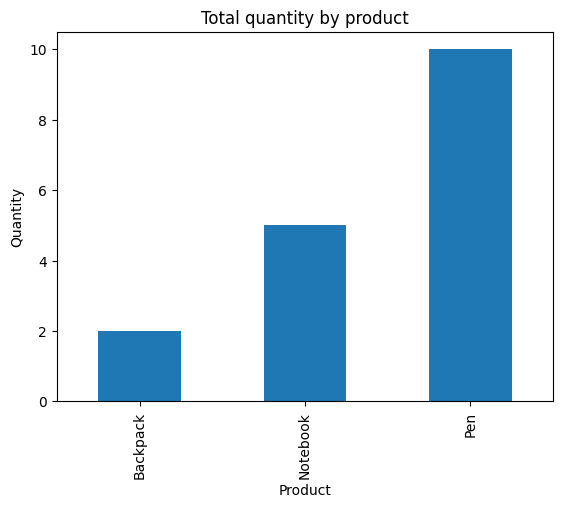

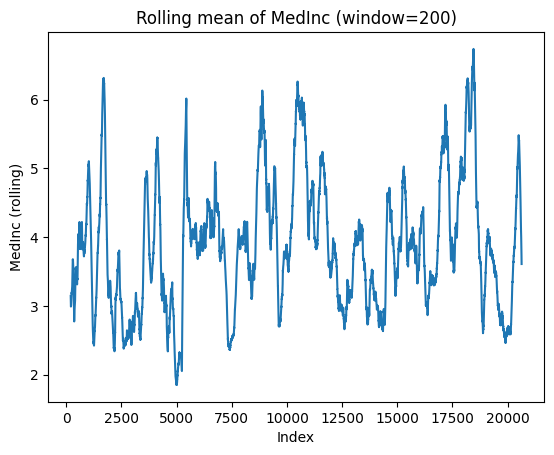

In [15]:
# First plot: total quantity sold per product (bar chart)
plt.figure()  # Create a new figure
sales.groupby("product")["qty"].sum().plot(
    kind="bar",
    title="Total quantity by product"
)
plt.xlabel("Product")   # Label the x-axis
plt.ylabel("Quantity")  # Label the y-axis
plt.show()              # Display the bar chart

# Second plot: rolling mean of median income (line chart)
plt.figure()  # Create another figure
df_cal["MedInc"].rolling(200).mean().plot(
    title="Rolling mean of MedInc (window=200)"
)
plt.xlabel("Index")               # X-axis represents the DataFrame index
plt.ylabel("MedInc (rolling)")    # Y-axis shows the smoothed median income
plt.show()                        # Display the line chart

## 16) Saving and exporting data

Common save methods:
- `.to_csv():` save as plain text (CSV)
- `.to_parquet():` save as efficient binary format
- `.to_json():` save as JSON data
- `.to_excel():` save as Excel spreadsheet  

Parquet format requires either **`pyarrow`** or **`fastparquet`**.  
See the full [I/O guide](https://pandas.pydata.org/docs/user_guide/io.html) for details.


In [16]:
# sales.to_csv("sales.csv", index=False)
# sales.to_parquet("sales.parquet")
# sales.to_json("sales.json", orient="records")
# sales.to_excel("sales.xlsx", index=False)  # .xlsx requires openpyxl